# NICHEVERSE on 10x Xenium

**Platform.** 10x Genomics Xenium in situ (imaging based, targeted gene panel, subcellular
transcript coordinates).

**Dataset (real).** A single Xenium tissue core from our clear cell renal cell carcinoma (RCC)
cohort, bundled with the package at `examples/data/xenium_rcc_core.h5ad`: **7,824 cells x 366
panel genes, 1 sample**. Raw integer counts are in `.X`, micron centroids in
`obsm['spatial']`, and the sample label in `obs['sample_id']`. The matching molecule table
(subcellular transcript coordinates) is bundled as
`examples/data/xenium_rcc_core_transcripts.parquet` with columns `x_location`, `y_location`,
`feature_name` (the Xenium convention).

**Units.** `obsm['spatial']` and the molecule coordinates are in **microns**.

This notebook trains on segmented counts and then shows the optional **transcript-context**
input, which concatenates the segmentation-free local molecular field (molecules within a
small radius of each nucleus) onto the segmented counts.

**A note on the encoder here.** The library default encoder is `mlp_deep`, and it is the right
default on a large diverse cohort (millions of cells). This example is a **single** fairly
homogeneous RCC core, where `mlp_plr` over-parameterizes and 256 codes exceed the core's
intrinsic diversity, so we use the plain `mlp` encoder with a 64-code codebook to get a
healthy, non-collapsed demo. Real cohort runs use `mlp_plr`, 256 codes, and about 300 epochs.


In [1]:
import anndata as ad, numpy as np
PLATFORM = "Xenium (RCC core)"
adata = ad.read_h5ad("/data1/lesliec/vijay/github/nicheverse/examples/data/xenium_rcc_core.h5ad")
assert "spatial" in adata.obsm and "sample_id" in adata.obs
print(adata)
print("raw counts:", bool(np.all(adata.X[:200].toarray() == np.round(adata.X[:200].toarray()))),
      "| samples:", adata.obs["sample_id"].nunique(),
      "| spatial units ~microns:", adata.obsm["spatial"].max(0).round(0))


AnnData object with n_obs × n_vars = 7824 × 366
    obs: 'sample_id'
    uns: 'source'
    obsm: 'spatial'
raw counts: True | samples: 1 | spatial units ~microns: [11410.  7180.]


## Configure and train

We build a `ModelConfig` (the architecture) and a `TrainConfig` (the optimization / spatial graph), then call `train_model`. The current library default encoder is `mlp_deep` (a SwiGLU pre-norm residual MLP) with the `vq` quantizer, and the neighborhood graph is `knn_radius` (radius 50 um, k = 20). We keep `batch_size=2048` rather than `'auto'`, because an over-large auto batch shrinks the number of optimizer steps per epoch and starves the codebook-diversity term. We run only a handful of demo epochs here so the notebook finishes in minutes; a production run uses about 300 epochs.

In [2]:
import os
from nicheverse.models import ModelConfig, HierarchicalVQVAE
from nicheverse.training import train_model, TrainConfig

ckpt = "/data1/lesliec/vijay/spatial_transcriptomicsg/my_work_Gosabopos/tmp/tmp/nb_xenium_demo"
os.makedirs(ckpt, exist_ok=True)

# The library default encoder is mlp_deep, and mlp_plr is a strong choice on a large diverse
# cohort. This example is a SINGLE fairly homogeneous RCC core (7,824 cells, 366 genes):
# mlp_plr over-parameterizes on so few cells and collapses the codebook, and 256 codes is
# far more than one core's intrinsic diversity. So for this small single-core demo we use the
# plain mlp encoder and a 64-code codebook (verified 64/64 codes active). On the full RCC
# cohort (millions of cells, ~300 epochs) mlp_plr with 256 codes is a recommended setting.
mc = ModelConfig(
    input_dim=int(adata.n_vars),
    cell_embedding_dim=64, cell_num_embeddings=64,   # 64 codes for one small core
    neighborhood_embedding_dim=256, neighborhood_num_embeddings=16,
    use_cross_attention=True,
    gene_names=tuple(adata.var_names.astype(str)),
    encoder_type="mlp",         # collapse-resistant on a single small core
    quantizer_type="vq",        # library default
)
tc = TrainConfig(
    num_epochs=40,              # demo; production ~300
    batch_size=2048,            # NOT 'auto' (protects codebook diversity)
    learning_rate=3e-4,
    spatial_graph="knn_radius", radius=50.0, k_neighbors=20,  # library defaults
    normalize=True, log1p=True, seed=49,
)
model, adata = train_model(adata, ckpt, model_config=mc, train_config=tc, sample_col="sample_id")
print("done ->", ckpt)


/data1/massaguj/yarlagad/conda/envs/annotforimst/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/data1/massaguj/yarlagad/conda/envs/annotforimst/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


epoch 1/40:   0%|          | 0/4 [00:00<?, ?it/s]

epoch 2/40:   0%|          | 0/4 [00:00<?, ?it/s]

epoch 3/40:   0%|          | 0/4 [00:00<?, ?it/s]

epoch 4/40:   0%|          | 0/4 [00:00<?, ?it/s]

...

epoch 37/40:   0%|          | 0/4 [00:00<?, ?it/s]

epoch 38/40:   0%|          | 0/4 [00:00<?, ?it/s]

epoch 39/40:   0%|          | 0/4 [00:00<?, ?it/s]

epoch 40/40:   0%|          | 0/4 [00:00<?, ?it/s]

done -> /data1/lesliec/vijay/spatial_transcriptomicsg/my_work_Gosabopos/tmp/tmp/nb_xenium_demo


## Optional: transcript-context input

Xenium ships subcellular transcript coordinates, so we can build the segmentation-free molecular field and attach it as an `obsm` matrix. This is the input used in `notebooks/02_transcript_context.ipynb`.

In [3]:
# --- Optional: transcript-context input (segmentation-free molecular field) ---
# Xenium is one of the platforms with a real per-cell molecule table bundled, so we can
# demonstrate transcript_context here. It adds an obsm matrix of local molecule counts
# (radius 7 um around each nucleus centroid) that can be concatenated onto segmented counts.
from nicheverse.data.transcript import transcript_context
feats = transcript_context(
    adata,
    transcripts="/data1/lesliec/vijay/github/nicheverse/examples/data/xenium_rcc_core_transcripts.parquet",
    radius=7.0, platform="xenium", sample_col="sample_id",
    key_added="transcript_context",
)
print("transcript_context obsm shape:", adata.obsm["transcript_context"].shape,
      "| nonzero cells:", int((adata.obsm["transcript_context"].sum(1) > 0).sum()))
# To train on the joint representation, concatenate counts + field into X and set
# input_dim = 2 * n_genes (see notebooks/02_transcript_context.ipynb for the full recipe).


transcript_context obsm shape: (7824, 366) | nonzero cells: 7824


## Inspect the learned codebook

`train_model` writes the per-cell code assignment to `hierarchical_cell_indices.npz` (key `indices`). A healthy run spreads cells across many codes; a collapsed run puts almost everything in one code.

In [4]:

# --- Load the codes the model just assigned to every cell ---
import numpy as np, json, os
idx = np.load(os.path.join(ckpt, "hierarchical_cell_indices.npz"))["indices"].ravel()
n_codes = int(model.config.cell_num_embeddings)
u, counts = np.unique(idx, return_counts=True)
print(f"{PLATFORM}: {len(idx)} cells assigned to {len(u)}/{n_codes} cell codes "
      f"(codebook usage {100*len(u)/n_codes:.0f}%)")


Xenium (RCC core): 7824 cells assigned to 64/64 cell codes (codebook usage 100%)


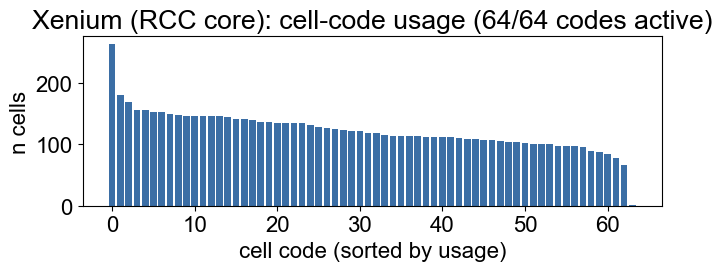

In [5]:

# --- Code-usage bar chart (how many cells fall in each active code) ---
%matplotlib inline
import matplotlib.pyplot as plt
order = np.argsort(counts)[::-1]
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(len(u)), counts[order], color="#3b6ea5")
ax.set_xlabel("cell code (sorted by usage)")
ax.set_ylabel("n cells")
ax.set_title(f"{PLATFORM}: cell-code usage ({len(u)}/{n_codes} codes active)")
plt.tight_layout()
plt.show()


## Top markers per code

For each used code we z-score its mean expression across codes and list the most enriched panel genes. This is a quick biological sanity check that codes track distinct cell states.

In [6]:

# --- Per-code top-marker table: mean log1p expression per code, z-scored across codes ---
import pandas as pd, scanpy as sc
work = adata.copy()
sc.pp.normalize_total(work); sc.pp.log1p(work)
X = work.X.toarray() if hasattr(work.X, "toarray") else np.asarray(work.X)
genes = np.asarray(work.var_names)
rows = []
for c in u:                                   # only codes that are actually used
    m = X[idx == c].mean(0)
    rows.append(m)
M = np.vstack(rows)                            # (n_used_codes, n_genes)
Z = (M - M.mean(0)) / (M.std(0) + 1e-8)        # z across codes, per gene
topk = 6
recs = []
for r, c in enumerate(u):
    top = genes[np.argsort(Z[r])[::-1][:topk]]
    recs.append({"cell_code": int(c), "n_cells": int((idx == c).sum()),
                 "top_markers": ", ".join(top)})
marker_tbl = pd.DataFrame(recs).sort_values("n_cells", ascending=False).reset_index(drop=True)
print(f"Top {topk} enriched genes per used cell code (first 15 codes shown):")
marker_tbl.head(15)


Top 6 enriched genes per used cell code (first 15 codes shown):


,cell_code,n_cells,top_markers
0,10,263,"SOX9, SOX4, CDH4, L1CAM, CD70, WT1"
1,16,180,"LAG3, GZMB, ITGAE, PRF1, TNFSF4, NKG7"
2,6,169,"TREM2, ITGAX, CD274, CD86, CD68, ITGAM"
3,15,156,"CEMIP, PDGFRA, LAMA2, RGS16, NPY1R, SPON1"
4,21,156,"MAFB, FCGR3A, C1orf162, FCGR1A, MS4A7, MS4A6A"
5,46,153,"ST18, CUX2, BCL2, MEOX1, GAD2, SLC26A4"
6,9,152,"TACR1, SOX17, MECOM, RNF144B, IGFBP3, JAG1"
7,22,150,"WNT4, THSD4, LAMP5, LAMA2, POSTN, DCN"
8,26,148,"C1QL3, MGST1, PTCHD4, NTNG1, WT1, CDH4"
9,18,147,"CTNNA3, COL25A1, KIT, P2RY12, IL7R, SOX11"


## Training runtime

The trainer records wall-clock time, throughput (cells/sec), and peak GPU memory to `training_runtime.json`.

In [7]:

# --- Training runtime report the trainer wrote (real timing on this GPU run) ---
rt_path = os.path.join(ckpt, "training_runtime.json")
runtime = json.load(open(rt_path))
print(json.dumps(runtime, indent=2))


{
  "total_seconds": 4.256,
  "total_hms": "0:00:04",
  "n_epochs": 40,
  "mean_epoch_seconds": 0.106,
  "cells_per_second": 73536.79,
  "iters_per_second": 37.595,
  "n_cells": 7824,
  "effective_batch_size": 2048,
  "n_batches_per_epoch": 4,
  "peak_gpu_gb": 0.173,
  "device": "cuda",
  "encoder_type": "mlp",
  "quantizer_type": "vq",
  "input_dim": 366
}
